# 💬 LangGraph: Customer Review Sentiment Routing Workflow

### 📌 Overview
This notebook implements **Sentiment-Based Dynamic Response Routing** using LangGraph's conditional edges:
1. **Sentiment Classifier (`find_sentiment`):** Analyzes incoming customer feedback and classifies the sentiment as either `positive` or `negative`.
2. **Conditional Router (`route_sentiment`):** Evaluates the classified sentiment and branches execution to the corresponding handler.
3. **Specialized Response Handlers:**
   * **Positive Branch (`positive_response`):** Generates a warm, personalized thank-you note highlighting customer loyalty.
   * **Negative Branch (`negative_response`):** Generates an empathetic, de-escalating apology that directly addresses the customer's stated grievances and offers remediation.

---

### 🗺️ Graph Topology

```text
                            ┌─────────────────────┐
                       ┌──► │  positive_response  │ ──┐
                       │    └─────────────────────┘   │
     ┌─────────┐       │ ["positive"]                 │       ┌───────┐
     │  START  │ ────► ⬡ find_sentiment               ├─────► │  END  │
     └─────────┘       │ ["negative"]                 │       └───────┘
                       └──► ┌─────────────────────┐   │
                            │  negative_response  │ ──┘
                            └─────────────────────┘
```

*Execution Flow:* `START` ➔ `find_sentiment` ➔ Conditional Router ➔ (`positive_response` OR `negative_response`) ➔ `END`

In [3]:
import os
from typing import Literal, NotRequired, TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

# Load environment variables
load_dotenv()

# Verify OpenRouter key
if not os.getenv("OPENROUTER_API_KEY"):
    raise ValueError(
        "OPENROUTER_API_KEY is missing. Please add it to your .env file: "
        "OPENROUTER_API_KEY=sk-or-v1-..."
    )

### 2. Initialize LLM via OpenRouter
We use `ChatOpenAI` configured with OpenRouter's `openrouter/free` router.

In [4]:
# OpenRouter configuration with Free Models Router
model = ChatOpenAI(
    model="openrouter/free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    temperature=0.3,
)

### 3. Define Sentiment Classification Schema
A Pydantic schema enforcing that the classification decision must strictly be either `'positive'` or `'negative'`.

In [5]:
class SentimentDecision(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(
        description="Classify whether the customer review sentiment is 'positive' or 'negative'."
    )


# Bind structured output to model
structured_model = model.with_structured_output(SentimentDecision)

### 4. Graph State Schema
The state contract defines:
* `review`: The raw customer review text (required input).
* `sentiment`: Classified sentiment label (`NotRequired` initially).
* `response`: Tailored customer support reply (`NotRequired` initially).

In [6]:
class ReviewState(TypedDict):
    review: str
    sentiment: NotRequired[Literal["positive", "negative"]]
    response: NotRequired[str]

### 5. Define Graph Nodes
* `find_sentiment`: Analyzes customer sentiment with built-in fallback resilience.
* `positive_response`: Crafts an enthusiastic appreciation note.
* `negative_response`: Drafts a professional apology and resolution plan.

In [7]:
def find_sentiment(state: ReviewState) -> dict:
    """Classifies customer review sentiment with automatic fallback resilience."""
    messages = [
        (
            "system",
            'You are an expert customer sentiment analyst. You must return ONLY a JSON object: {"sentiment": "positive"} or {"sentiment": "negative"}.',
        ),
        ("human", f"Analyze this customer review:\n\n{state['review']}"),
    ]

    try:
        # 1. Attempt structured Pydantic extraction
        result: SentimentDecision = structured_model.invoke(messages)
        sentiment = result.sentiment
    except Exception:
        # 2. Resilient Fallback: Inspect raw response if model returns plain text
        raw_text = model.invoke(messages).content.lower()
        sentiment = "positive" if "positive" in raw_text else "negative"

    return {"sentiment": sentiment}


def positive_response(state: ReviewState) -> dict:
    """Generates an engaging, warm thank-you message for positive feedback."""
    messages = [
        (
            "system",
            "You are a friendly and professional customer success manager. "
            "Write a warm, personalized thank-you note expressing genuine gratitude.",
        ),
        ("human", f"Customer Review:\n{state['review']}"),
    ]
    response = model.invoke(messages)
    return {"response": str(response.content)}


def negative_response(state: ReviewState) -> dict:
    """Generates an empathetic, de-escalating customer support response addressing issues."""
    messages = [
        (
            "system",
            "You are a senior customer resolution specialist. "
            "Acknowledge the customer's frustration with deep empathy, apologize sincerely, "
            "address the specific pain points mentioned, and propose a concrete resolution.",
        ),
        ("human", f"Customer Review:\n{state['review']}"),
    ]
    response = model.invoke(messages)
    return {"response": str(response.content)}

### 6. Define Conditional Routing Function
The routing function checks the classified `sentiment` and returns the destination node name.

In [8]:
def route_sentiment(
    state: ReviewState,
) -> Literal["positive_response", "negative_response"]:
    """Conditional router directing execution to the appropriate response generator."""
    if state.get("sentiment") == "positive":
        return "positive_response"
    return "negative_response"

### 7. Build and Compile the Routing Graph
We wire `START ➔ find_sentiment`, attach `add_conditional_edges()`, and route both specialized handlers to `END`.

In [9]:
# 1. Initialize StateGraph
builder = StateGraph(ReviewState)

# 2. Register all nodes
builder.add_node("find_sentiment", find_sentiment)
builder.add_node("positive_response", positive_response)
builder.add_node("negative_response", negative_response)

# 3. Add entry edge
builder.add_edge(START, "find_sentiment")

# 4. Add conditional routing edges
builder.add_conditional_edges("find_sentiment", route_sentiment)

# 5. Add exit edges to END
builder.add_edge("positive_response", END)
builder.add_edge("negative_response", END)

# 6. Compile workflow
workflow = builder.compile()

### 8. Visualize Graph Topology
Evaluating the compiled `workflow` object directly renders the interactive diagram.

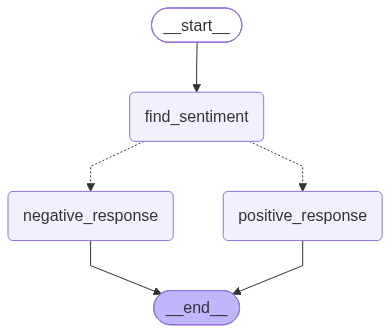

In [10]:
workflow

### 9. Execute the Routing Workflow
We test both branches:
1. **Positive Review:** Should route to `positive_response`.
2. **Negative Review:** Should route to `negative_response`.

In [11]:
# --- Test Case 1: Positive Review ---
print("=== TEST CASE 1: POSITIVE REVIEW ===")
positive_input = {
    "review": "The wireless headphones arrived in two days and the sound quality is breathtaking! Best purchase of the year."
}
positive_result = workflow.invoke(positive_input)
print(f"Sentiment: {positive_result['sentiment']}")
print(f"Generated Response:\n{positive_result['response']}\n")

# --- Test Case 2: Negative Review ---
print("=== TEST CASE 2: NEGATIVE REVIEW ===")
negative_input = {
    "review": "Extremely disappointed. The package was damaged, the left earbud doesn't charge, and customer support ignored my email for a week."
}
negative_result = workflow.invoke(negative_input)
print(f"Sentiment: {negative_result['sentiment']}")
print(f"Generated Response:\n{negative_result['response']}")

=== TEST CASE 1: POSITIVE REVIEW ===
Sentiment: positive
Generated Response:
Subject: Thank You for Your Five‑Star Experience! 🎧

Dear [Customer Name],

I hope this note finds you well! I’m thrilled to hear that your new wireless headphones arrived in just two days and that the sound quality has already exceeded your expectations. It’s truly rewarding to know our product has made such a positive impact—receiving feedback like yours, calling them “the best purchase of the year,” is what drives us to keep striving for excellence.

Your satisfaction is our top priority, and I’d love to ensure your experience continues to be as delightful as the first moment you unpacked them. If there’s anything else I can help with—whether it’s pairing tips, warranty information, or any other questions—just let me know. 

Thank you again for choosing us and for sharing your enthusiasm. We can’t wait to see what other adventures your headphones take you on!

Warmest regards,

[Your Name]  
Customer Succes